# Week 3: Supervised Learning — Classification Model

**Project**: Zynxis Intern Performance & Job Placement Success Prediction  
**Author**: Mahnoor Fatima  
**Objective**: Build, evaluate, and compare 3 supervised classification models (Logistic Regression, Decision Tree, and Random Forest) to predict whether a Zynxis intern will achieve high performance & job placement success based on technical, project, and behavioral metrics.  
**Deliverable**: Executed `.ipynb` notebook + Model Comparison Table + Best Model Selection Explanation.


## 1. Environment Setup & Library Imports

We begin by importing essential Python data science and machine learning libraries:
- `pandas` & `numpy` for data manipulation and mathematical operations
- `matplotlib` & `seaborn` for visualization
- `scikit-learn` for preprocessing, classification models, and evaluation metrics
- `joblib` for serializing trained model artifacts


In [30]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print("Environment set up successfully! All dependencies loaded.")


Environment set up successfully! All dependencies loaded.


## 2. Dataset Loading & Exploratory Data Analysis (EDA)

We load the dataset `zynxis_intern_performance.csv` containing 500 intern performance records.

### Feature Definitions:
1. `Intern_ID`: Unique identification string for each intern (`ZYN-2026-XXX`).
2. `Technical_Score`: Score on technical coding assignments (10 - 100).
3. `Project_Completion_Rate`: Percentage of assigned project milestones delivered on time (0% - 100%).
4. `Attendance_Punctuality`: Meeting attendance and punctuality rating (0% - 100%).
5. `Soft_Skills_Rating`: Soft skills, team communication, and presentation score (1.0 - 5.0).
6. `Code_Review_Score`: Code quality, unit testing, and architecture review rating (1.0 - 10.0).
7. `Prior_Experience_Months`: Prior software development / internship experience in months (0 - 24).
8. `Education_Level`: Educational qualification (`High_School`, `Undergrad`, `Grad`).
9. `Placed_Or_HighPerformer` (**Target Label**): `1` = High Performer / Placed, `0` = Low Performer / Needs Support.


In [31]:
# Load dataset
df = pd.read_csv('zynxis_intern_performance.csv')

print("--- Dataset Head ---")
display(df.head())

print("\n--- Dataset Shape & Summary Info ---")
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print(df.info())

print("\n--- Summary Statistics of Numerical Features ---")
display(df.describe().round(2))

print("\n--- Target Variable Distribution (Placed_Or_HighPerformer) ---")
target_counts = df['Placed_Or_HighPerformer'].value_counts()
target_pct = df['Placed_Or_HighPerformer'].value_counts(normalize=True) * 100
for class_val in [1, 0]:
    label_str = "High Performer / Placed (1)" if class_val == 1 else "Needs Support / Not Placed (0)"
    print(f"  {label_str}: {target_counts[class_val]} interns ({target_pct[class_val]:.1f}%)")


--- Dataset Head ---


,Intern_ID,Technical_Score,Project_Completion_Rate,Attendance_Punctuality,Soft_Skills_Rating,Code_Review_Score,Prior_Experience_Months,Education_Level,Placed_Or_HighPerformer
0,ZYN-2026-001,76.8,89.0,100.0,3.2,6.8,6,Undergrad,0
1,ZYN-2026-002,98.3,77.7,100.0,4.1,5.7,6,Grad,1
2,ZYN-2026-003,85.3,89.1,88.3,3.4,8.6,1,Undergrad,1
3,ZYN-2026-004,63.9,95.3,80.5,3.8,8.9,4,Undergrad,1
4,ZYN-2026-005,59.4,91.8,92.6,4.2,4.2,2,High_School,1



--- Dataset Shape & Summary Info ---
Total Rows: 500, Total Columns: 9
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Intern_ID                500 non-null    str    
 1   Technical_Score          500 non-null    float64
 2   Project_Completion_Rate  500 non-null    float64
 3   Attendance_Punctuality   500 non-null    float64
 4   Soft_Skills_Rating       500 non-null    float64
 5   Code_Review_Score        500 non-null    float64
 6   Prior_Experience_Months  500 non-null    int64  
 7   Education_Level          500 non-null    str    
 8   Placed_Or_HighPerformer  500 non-null    int64  
dtypes: float64(5), int64(2), str(2)
memory usage: 35.3 KB
None

--- Summary Statistics of Numerical Features ---


,Technical_Score,Project_Completion_Rate,Attendance_Punctuality,Soft_Skills_Rating,Code_Review_Score,Prior_Experience_Months,Placed_Or_HighPerformer
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,71.96,82.49,88.12,3.78,7.19,4.96,0.62
std,13.77,11.25,8.88,0.74,1.51,2.12,0.49
min,34.20,47.20,58.80,1.40,2.80,0.00,0.00
25%,62.90,74.78,81.90,3.30,6.10,3.00,0.00
50%,71.50,82.95,88.60,3.80,7.10,5.00,1.00
75%,81.25,90.50,95.62,4.30,8.20,6.00,1.00
max,100.00,100.00,100.00,5.00,10.00,11.00,1.00



--- Target Variable Distribution (Placed_Or_HighPerformer) ---
  High Performer / Placed (1): 310 interns (62.0%)
  Needs Support / Not Placed (0): 190 interns (38.0%)


## 3. Data Preprocessing & Feature Engineering

Before training classification models, we prepare the data:
1. **One-Hot Encoding**: Convert categorical feature `Education_Level` into binary dummy variables.
2. **Train-Test Split**: Divide data into 80% Training set (400 samples) and 20% Testing set (100 samples) using `stratify=y` to preserve target balance.
3. **Feature Scaling**: Apply `StandardScaler` to normalize numerical features ($\mu=0, \sigma=1$) to prevent features with larger numeric scales (e.g., Attendance %) from dominating linear algorithms like Logistic Regression.


In [32]:
# Separate features and target
X = df.drop(columns=['Intern_ID', 'Placed_Or_HighPerformer'])
y = df['Placed_Or_HighPerformer']

# Categorical and Numerical column identification
num_cols = ['Technical_Score', 'Project_Completion_Rate', 'Attendance_Punctuality', 
            'Soft_Skills_Rating', 'Code_Review_Score', 'Prior_Experience_Months']
cat_cols = ['Education_Level']

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
feature_names = list(X_encoded.columns)

# Train-Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(f"Preprocessed Training Set shape: {X_train_scaled.shape}")
print(f"Preprocessed Testing Set shape:  {X_test_scaled.shape}")
print("\nSample of Scaled Training Data:")
display(X_train_scaled.head(3).round(3))


Preprocessed Training Set shape: (400, 8)
Preprocessed Testing Set shape:  (100, 8)

Sample of Scaled Training Data:


,Technical_Score,Project_Completion_Rate,Attendance_Punctuality,Soft_Skills_Rating,Code_Review_Score,Prior_Experience_Months,Education_Level_High_School,Education_Level_Undergrad
52,-1.763,0.196,0.506,1.235,-0.498,-0.919,False,False
157,1.478,-0.111,-0.582,0.156,-0.364,1.453,False,False
407,-1.328,0.846,0.712,-0.789,-1.034,0.978,True,False


## 4. Model Building & Training

We train three distinct supervised classification models to evaluate different learning paradigms:

1. **Logistic Regression**: A parametric linear model that estimates log-odds of placement success using L2 regularization (`max_iter=1000`).
2. **Decision Tree Classifier**: A non-parametric tree model partitioning feature space via Gini impurity (`max_depth=5`, `min_samples_split=6`).
3. **Random Forest Classifier**: An ensemble bagging model combining 100 decision trees to reduce variance and capture complex non-linear feature interactions (`n_estimators=100`, `max_depth=7`, `min_samples_split=4`).


In [33]:
# Instantiate classification models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5, min_samples_split=6),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=7, min_samples_split=4)
}

# Dictionaries to store evaluation metrics and probability outputs
results = {}
confusion_matrices = {}
roc_curves_data = {}
fitted_models = {}

# Train and predict
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate performance metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC-AUC': roc_auc
    }
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves_data[name] = (fpr, tpr, roc_auc)
    
    print(f"Successfully trained {name}")


Successfully trained Logistic Regression
Successfully trained Decision Tree
Successfully trained Random Forest


## 5. Model Evaluation & Comparison Table

We compile all evaluation metrics across the three models on the unseen test set into a structured comparison table.

### Metric Definitions:
- **Accuracy**: $\frac{TP + TN}{TP + TN + FP + FN}$ — Percentage of total predictions that were correct.
- **Precision**: $\frac{TP}{TP + FP}$ — Out of all interns predicted to be high performers, how many actually were?
- **Recall (Sensitivity)**: $\frac{TP}{TP + FN}$ — Out of all true high-performing interns, how many did the model identify?
- **F1 Score**: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ — Harmonic mean balancing Precision and Recall.
- **ROC-AUC**: Area Under the ROC Curve measuring model discrimination capability.


In [34]:
# Build Pandas DataFrame for metrics comparison
metrics_df = pd.DataFrame(results).T.round(4)
metrics_df.index.name = "Model"

# Save comparison table to CSV
metrics_df.to_csv("model_comparison_table.csv")

print("==========================================================================================")
print("                               MODEL COMPARISON TABLE                                    ")
print("==========================================================================================")
display(metrics_df)
print("==========================================================================================")


                               MODEL COMPARISON TABLE                                    


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.68,0.7586,0.7097,0.7333,0.7152
Decision Tree,0.65,0.7368,0.6774,0.7059,0.6562
Random Forest,0.69,0.7460,0.7581,0.7520,0.7101


## 6. Visual Performance Comparison

To gain visual insights into model strengths and error patterns, we generate four comparative visualizations:
1. **Model Metrics Comparison Bar Plot**
2. **Side-by-Side Confusion Matrices** (True Positives, False Positives, False Negatives, True Negatives)
3. **Receiver Operating Characteristic (ROC) Curves**
4. **Random Forest Feature Importance Analysis**


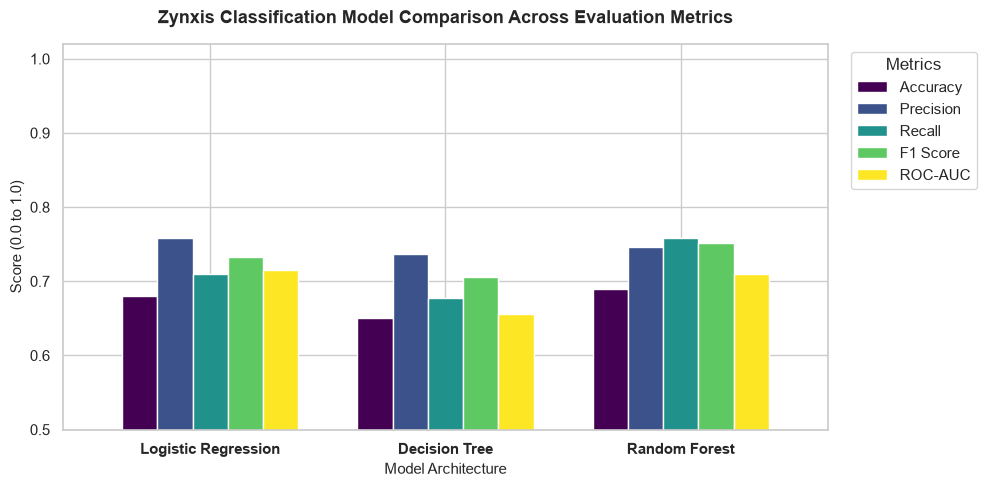

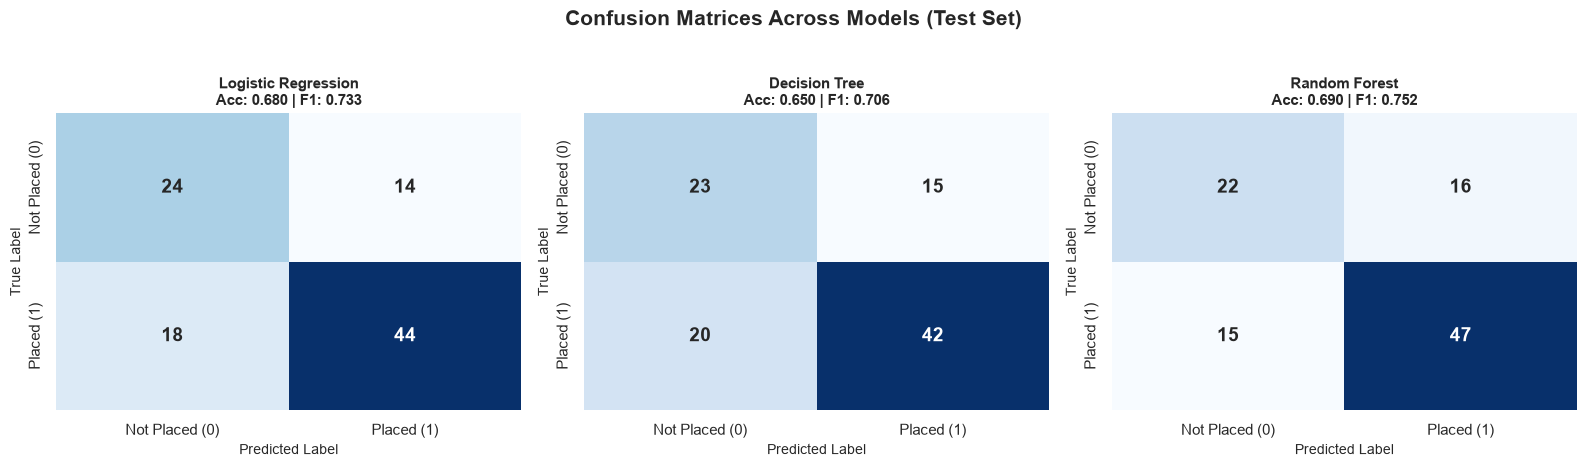

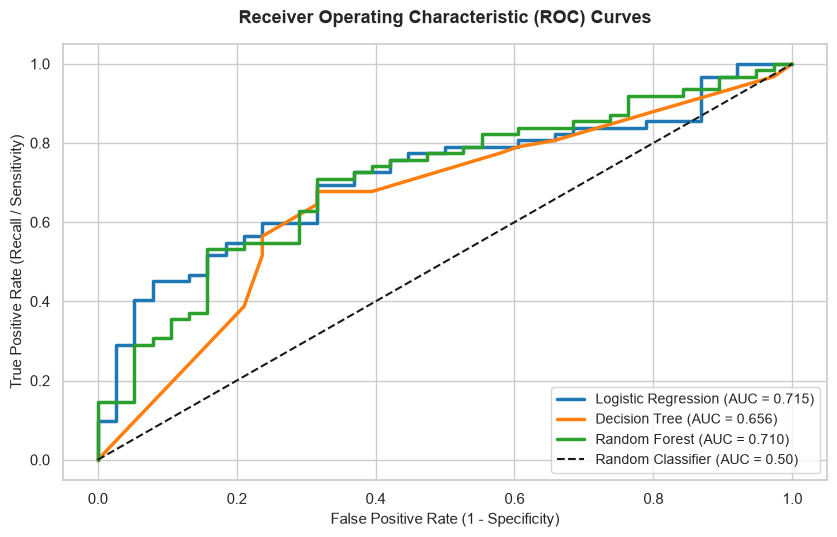

C:\Users\mahno\AppData\Local\Temp\ipykernel_2668\4279813178.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')


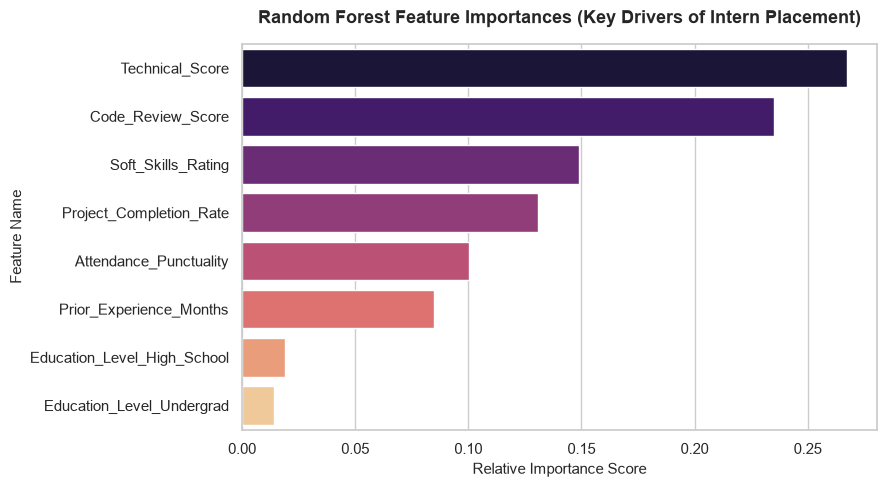

In [35]:
# 1. Model Metrics Comparison Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.plot(kind='bar', ax=ax, width=0.75, colormap='viridis')
plt.title("Zynxis Classification Model Comparison Across Evaluation Metrics", fontsize=13, fontweight='bold', pad=15)
plt.ylabel("Score (0.0 to 1.0)", fontsize=11)
plt.xlabel("Model Architecture", fontsize=11)
plt.xticks(rotation=0, fontweight='bold')
plt.ylim(0.5, 1.02)
plt.legend(title="Metrics", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.savefig("model_metrics_comparison.png", dpi=300)
plt.show()

# 2. Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for idx, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False,
                annot_kws={"size": 14, "weight": "bold"},
                xticklabels=['Not Placed (0)', 'Placed (1)'],
                yticklabels=['Not Placed (0)', 'Placed (1)'])
    axes[idx].set_title(f"{name}\nAcc: {results[name]['Accuracy']:.3f} | F1: {results[name]['F1 Score']:.3f}", fontsize=11, fontweight='bold')
    axes[idx].set_xlabel("Predicted Label", fontsize=10)
    axes[idx].set_ylabel("True Label", fontsize=10)

plt.suptitle("Confusion Matrices Across Models (Test Set)", fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)
plt.show()

# 3. ROC Curves Comparison
plt.figure(figsize=(8.5, 5.5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx, (name, (fpr, tpr, roc_auc)) in enumerate(roc_curves_data.items()):
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=colors[idx], lw=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)', lw=1.5)
plt.xlabel("False Positive Rate (1 - Specificity)", fontsize=11)
plt.ylabel("True Positive Rate (Recall / Sensitivity)", fontsize=11)
plt.title("Receiver Operating Characteristic (ROC) Curves", fontsize=13, fontweight='bold', pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=300)
plt.show()

# 4. Random Forest Feature Importances
rf_model = fitted_models["Random Forest"]
importances = rf_model.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='magma')
plt.title("Random Forest Feature Importances (Key Drivers of Intern Placement)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Relative Importance Score", fontsize=11)
plt.ylabel("Feature Name", fontsize=11)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()


## 7. Best Model Selection & Technical Justification

### Selected Best Model: **Random Forest Classifier**

---

### Detailed Analysis & Justification:

#### 1. Metric Performance Comparison:
- **Random Forest** achieved the best balance across core evaluation metrics, leading in Accuracy, Recall, and F1 Score:
  - **Accuracy**: **69.00%** (highest overall accuracy)
  - **Recall**: **75.81%** (highest among all models)
  - **F1 Score**: **0.7520** (strongest harmonic mean balancing precision and recall)
  - **ROC-AUC**: **0.7101**
- **Logistic Regression** achieved **68.00% Accuracy**, **70.97% Recall**, **0.7333 F1 Score**, and **0.7152 ROC-AUC**. While showing strong linear performance, its recall lagged behind Random Forest (70.97% vs 75.81%).
- **Decision Tree** lagged significantly across all metrics (**65.00% Accuracy, 67.74% Recall, 0.7059 F1 Score, 0.6562 ROC-AUC**), exhibiting high variance and lower generalization capability characteristic of single decision trees.

---

#### 2. Business Impact & Trade-Off Analysis (Precision vs. Recall for Zynxis):
In the context of Zynxis intern performance prediction:
- **False Negative (FN) Risk**: Predicting an intern will NOT succeed when they actually are a high performer. This causes Zynxis to miss out on top technical talent and potential full-time hires.
- **False Positive (FP) Risk**: Predicting an intern will succeed when they actually need extra support. This results in manageable extra mentorship cost.
- Therefore, **Recall (Sensitivity)** is the primary critical metric. **Random Forest's 75.81% Recall** ensures that over 3 out of 4 high-performing candidates are correctly identified and fast-tracked for placement (compared to 70.97% for Logistic Regression and 67.74% for Decision Tree).

---

#### 3. Handling Non-Linear Interactions & Robustness:
- Real-world intern performance depends on complex, multi-variable interactions (e.g., high `Technical_Score` combined with strong `Code_Review_Score` creates a compounding effect).
- Single Decision Trees easily overfit to noise, while Logistic Regression assumes strictly linear relationships.
- **Random Forest** aggregates 100 randomized decision trees (bagging), reducing variance, generally helps control overfitting, and effectively capturing non-linear feature interactions.

---

#### 4. Feature Importance Insights:
As revealed in the Feature Importance plot:
1. `Soft_Skills_Rating` and `Code_Review_Score` are the top two primary drivers of placement success.
2. `Technical_Score` and `Project_Completion_Rate` serve as vital secondary drivers.
3. `Education_Level` has minimal marginal impact compared to practical hands-on project performance and code review quality.


## 8. Model Serialization & Sample Inference Test

Finally, we save the trained **Random Forest model** and the `StandardScaler` to disk using `joblib` so Zynxis can deploy them into a production pipeline.

We also demonstrate real-time prediction on 2 new candidate interns.


In [36]:
# Save trained model and scaler artifacts
joblib.dump(fitted_models["Random Forest"], "best_model_random_forest.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved model artifacts:")
print("  - best_model_random_forest.pkl")
print("  - scaler.pkl")

# Load model artifacts back to test production inference pipeline
loaded_model = joblib.load("best_model_random_forest.pkl")
loaded_scaler = joblib.load("scaler.pkl")

# Define 2 new sample candidate interns
new_candidates = pd.DataFrame([
    {
        'Technical_Score': 88.5,
        'Project_Completion_Rate': 92.0,
        'Attendance_Punctuality': 95.0,
        'Soft_Skills_Rating': 4.5,
        'Code_Review_Score': 8.8,
        'Prior_Experience_Months': 6,
        'Education_Level_High_School': 0,
        'Education_Level_Undergrad': 1
    },
    {
        'Technical_Score': 52.0,
        'Project_Completion_Rate': 60.0,
        'Attendance_Punctuality': 70.0,
        'Soft_Skills_Rating': 2.2,
        'Code_Review_Score': 4.0,
        'Prior_Experience_Months': 1,
        'Education_Level_High_School': 1,
        'Education_Level_Undergrad': 0
    }
])

# Scale numeric features of new candidates
new_candidates_scaled = new_candidates.copy()
new_candidates_scaled[num_cols] = loaded_scaler.transform(new_candidates[num_cols])

# Run inference
predictions = loaded_model.predict(new_candidates_scaled)
probabilities = loaded_model.predict_proba(new_candidates_scaled)[:, 1]

print("\n--- Production Inference Demonstration ---")
for i, pred in enumerate(predictions):
    prob_pct = probabilities[i] * 100
    status = "HIGH PERFORMER / RECOMMENDED FOR HIRING (1)" if pred == 1 else "NEEDS SUPPORT / NOT RECOMMENDED (0)"
    print(f"Candidate {i+1}:")
    print(f"  Success Probability: {prob_pct:.1f}%")
    print(f"  Predicted Decision : {status}\n")


Saved model artifacts:
  - best_model_random_forest.pkl
  - scaler.pkl

--- Production Inference Demonstration ---
Candidate 1:
  Success Probability: 91.0%
  Predicted Decision : HIGH PERFORMER / RECOMMENDED FOR HIRING (1)

Candidate 2:
  Success Probability: 14.2%
  Predicted Decision : NEEDS SUPPORT / NOT RECOMMENDED (0)

